## Evaluate Audioseal with ASVspoof

In [1]:
import os
from notebook import play_audio, plot_waveform_and_specgram, plot_waveform_and_melspec
base_path = r'D:\dataset\DS_10283_3336\LA\LA'
audio_path = os.path.join(base_path, 'ASVspoof2019_LA_dev', 'flac')
protocol_file = os.path.join(base_path, 'ASVspoof2019_LA_cm_protocols', 'ASVspoof2019.LA.cm.dev.trl.txt')

audio_files = []
spoof_labels = []
err_labels = []
acc_labels = []

with open(protocol_file, 'r') as f:
    for line in f:
        parts = line.strip().split()
        file_id = parts[1]
        label = parts[-1]
        filepath = os.path.join(audio_path, file_id + '.flac')
        if os.path.exists(filepath):
            audio_files.append(filepath)
            spoof_labels.append(1 if label == 'spoof' else 0)
            err_labels.append(0)
            acc_labels.append(1)

print(f"analysis completed. There are {len(audio_files)} audios in total")

analysis completed. There are 24844 audios in total


In [4]:
sum(spoof_labels)

22296

#### First, we calculate the false detection rate of non-watermarked audio being incorrectly classified as watermarked.

In [9]:
import torch
import torchaudio
from audioseal import AudioSeal

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = AudioSeal.load_generator("audioseal_wm_16bits").to(device)
detector = AudioSeal.load_detector(("audioseal_detector_16bits")).to(device)

waveforms, srs = [], []
def get_score(filepath):
    waveform, sr = torchaudio.load(filepath)
    with torch.no_grad():
        waveforms.append(waveform)
        srs.append(sr)
        score, message = detector.detect_watermark(waveform.unsqueeze(0).to(device), sample_rate = sr, message_threshold=0.5)
    return float(score)

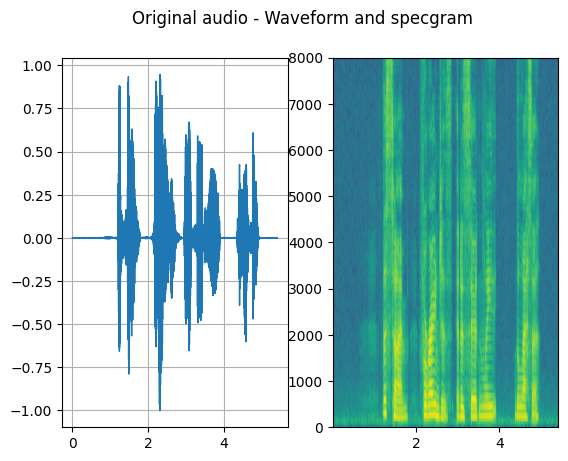

In [10]:
from notebook import play_audio, plot_waveform_and_specgram
waveform, sr = torchaudio.load(audio_files[0])
plot_waveform_and_specgram(waveform.unsqueeze(0), sr, title="Original audio")

In [11]:
scores = []

for i, path in enumerate(audio_files):
    score = get_score(path)
    scores.append(score)
    if i % 100 == 0:
        print(f"Processed {i}/{len(audio_files)}")

Processed 0/24844
Processed 100/24844
Processed 200/24844
Processed 300/24844
Processed 400/24844
Processed 500/24844
Processed 600/24844
Processed 700/24844
Processed 800/24844
Processed 900/24844
Processed 1000/24844
Processed 1100/24844
Processed 1200/24844
Processed 1300/24844
Processed 1400/24844
Processed 1500/24844
Processed 1600/24844
Processed 1700/24844
Processed 1800/24844
Processed 1900/24844
Processed 2000/24844
Processed 2100/24844
Processed 2200/24844
Processed 2300/24844
Processed 2400/24844
Processed 2500/24844
Processed 2600/24844
Processed 2700/24844
Processed 2800/24844
Processed 2900/24844
Processed 3000/24844
Processed 3100/24844
Processed 3200/24844
Processed 3300/24844
Processed 3400/24844
Processed 3500/24844
Processed 3600/24844
Processed 3700/24844
Processed 3800/24844
Processed 3900/24844
Processed 4000/24844
Processed 4100/24844
Processed 4200/24844
Processed 4300/24844
Processed 4400/24844
Processed 4500/24844
Processed 4600/24844
Processed 4700/24844
Proc

In [16]:
for waveform in waveforms:
    if not torch.all(torch.abs(waveform) <= 1):
        print("there is a audio without normalization")
        break

In [17]:
for sr in srs:
    if sr != 16000:
        print("there is a audio's sr not 16000")
        break

In [28]:
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, roc_curve

threshold = 0.5
preds = [1 if s > threshold else 0 for s in scores]

acc = accuracy_score(err_labels, preds)
# tn, fp, fn, tp = confusion_matrix(y_true = err_labels, y_pred = preds, labels = [0,1]).ravel()
# tpr = tp / (tp + fn)
# fpr = fp / (fp + tn)
# auc = roc_auc_score(err_labels, scores)

print(f"\n🎯 评估结果（阈值 = {threshold}）")
print(f"不带水印音频的检测Accuracy: {acc:.3f}")
# print(f"TPR: {tpr:.3f}")
# print(f"FPR: {fpr:.3f}")
# print(f"AUC: {auc:.3f}")


🎯 评估结果（阈值 = 0.5）
不带水印音频的检测Accuracy: 1.000


#### Then, we embed watermarks into all audio samples in the test set and compute the detection rate of Audioseal.

In [24]:
def embed_mark(filepath):
    waveform, sr = torchaudio.load(filepath)
    waveform = waveform.unsqueeze(0).to(device)
    with torch.no_grad():
        watermark = model.get_watermark(waveform, sample_rate=sr)
        watermarked_waveform = waveform + watermark
        watermarked_waveform = model(waveform, sample_rate=sr, alpha=1)
    return watermarked_waveform

In [4]:
watermarked_audio_list = []
for i, path in enumerate(audio_files):
    watermarked_audio = embed_mark(path)
    watermarked_audio_list.append(watermarked_audio)
    if i % 100 == 0:
        print(f"Processed {i}/{len(audio_files)}")

NameError: name 'audio_files' is not defined

In [26]:
scores = []
for i,watermarked_audio in enumerate(watermarked_audio_list):
    with torch.no_grad():
        score, message = detector.detect_watermark(watermarked_audio.to(device), sample_rate = sr, message_threshold=0.5)
        scores.append(score)
    if i % 100 == 0:
        print(f"Processed {i}/{len(watermarked_audio_list)}")

Processed 0/24844
Processed 100/24844
Processed 200/24844
Processed 300/24844
Processed 400/24844
Processed 500/24844
Processed 600/24844
Processed 700/24844
Processed 800/24844
Processed 900/24844
Processed 1000/24844
Processed 1100/24844
Processed 1200/24844
Processed 1300/24844
Processed 1400/24844
Processed 1500/24844
Processed 1600/24844
Processed 1700/24844
Processed 1800/24844
Processed 1900/24844
Processed 2000/24844
Processed 2100/24844
Processed 2200/24844
Processed 2300/24844
Processed 2400/24844
Processed 2500/24844
Processed 2600/24844
Processed 2700/24844
Processed 2800/24844
Processed 2900/24844
Processed 3000/24844
Processed 3100/24844
Processed 3200/24844
Processed 3300/24844
Processed 3400/24844
Processed 3500/24844
Processed 3600/24844
Processed 3700/24844
Processed 3800/24844
Processed 3900/24844
Processed 4000/24844
Processed 4100/24844
Processed 4200/24844
Processed 4300/24844
Processed 4400/24844
Processed 4500/24844
Processed 4600/24844
Processed 4700/24844
Proc

In [20]:
# audios, sr = torchaudio.load(audio_files[0])
# audios = audios.unsqueeze(0).to(device)
# play_audio(audios, sample_rate = sr)
# watermark = model.get_watermark(audios, sample_rate=sr)
# watermarked_audio = audios + watermark
#
# # Alternatively, you can also call forward() function directly with different tune-down / tune-up rate
# watermarked_audio = model(audios, sample_rate=sr, alpha=1)
# watermarked = embed_mark(audio_files[0])
# detector.detect_watermark(watermarked.to(device), sample_rate = sr, message_threshold=0.5)

In [27]:
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, roc_curve

threshold = 0.5
preds = [1 if s > threshold else 0 for s in scores]

acc = accuracy_score(acc_labels, preds)
# tn, fp, fn, tp = confusion_matrix(y_true = err_labels, y_pred = preds, labels = [0,1]).ravel()
# tpr = tp / (tp + fn)
# fpr = fp / (fp + tn)
# auc = roc_auc_score(err_labels, scores)

print(f"\n🎯 评估结果（阈值 = {threshold}）")
print(f"带水印音频的检测Accuracy: {acc:.3f}")
# print(f"TPR: {tpr:.3f}")
# print(f"FPR: {fpr:.3f}")
# print(f"AUC: {auc:.3f}")


🎯 评估结果（阈值 = 0.5）
带水印音频的检测Accuracy: 1.000


In [28]:
scores

[1.0,
 1.0,
 1.0,
 0.9999999403953552,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 0.9999999403953552,
 1.0,
 0.9999999403953552,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 0.9999999403953552,
 1.0,
 1.0,
 1.0,
 0.9999999403953552,
 1.0,
 0.9999999403953552,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 0.9999999403953552,
 0.9999999403953552,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 0.9999999403953552,
 1.0,
 0.9999999403953552,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 0.9999999403953552,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 0.9999999403953552,
 1.0,
 1.0,
 0.9999999403953552,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 0.9999999403953552,
 1.0,
 1.0,
 0.9999999403953552,
 1.0,
 1.0,
 0.9999999403953552,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 0.9999999

In [32]:
# import matplotlib.pyplot as plt
#
# fpr_vals, tpr_vals, _ = roc_curve(labels, scores)
#
# plt.figure(figsize=(6, 5))
# plt.plot(fpr_vals, tpr_vals, label=f'AUC = {auc:.3f}')
# plt.plot([0, 1], [0, 1], 'k--')
# plt.xlabel("False Positive Rate")
# plt.ylabel("True Positive Rate")
# plt.title("ROC Curve - AudioSeal on ASVspoof2019 LA")
# plt.legend()
# plt.grid(True)
# plt.show()